# Notebook 05a - DistilBERT Fine-Tuning

## Environment Setup and Library Imports

This section initialises the environment and imports all required libraries and configuration parameters for the DistilBERT training pipeline.

- Extends the Python path to enable access to project modules from the parent directory
- Imports core libraries for:
  - Data manipulation and numerical computation
  - Model training using PyTorch and Transformers
  - Evaluation and performance metrics
  - Visualisation and warning management
- Loads experiment configuration parameters to ensure consistency and reproducibility

In [1]:
# System Path Configuration
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np
import pickle

# PyTorch Utilities
import torch
from torch.utils.data import Dataset

# Visualisation and Warning Control
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Transformers Components
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

# Evaluation Library
import evaluate

# Project Configuration Parameters
from config import (
    LABELLED_DATASET,
    DISTILBERT_MODEL_ID,
    DISTILBERT_DIR,
    DISTILBERT_RESULTS_CSV,
    DISTILBERT_PREDS_PKL,
    PLOTS_DIR,
    MAX_LENGTH,
    NUM_EPOCHS,
    BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_STEPS,
    EARLY_STOPPING_PATIENCE,
    RANDOM_STATE,
    TEST_SIZE,
    VAL_SIZE,
    NUM_LABELS,
)


# Create Feature Analysis Plot Save Directory
DISTILBERT_PLOTS_DIR = PLOTS_DIR / "distilbert_model"
DISTILBERT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

## Reproducibility, Data Preparation, and Class Imbalance Handling

This section initialises reproducibility settings, prepares the dataset, and computes class weights for imbalanced learning.

- Sets a fixed random seed to ensure consistent experimental results
- Configures cuDNN settings to optimise GPU performance
- Detects available hardware and enables GPU acceleration where possible
- Loads the labelled dataset and extracts:
  - Text narratives as input features
  - Binary readmission labels as targets
- Performs a two-stage stratified split to create:
  - Training set
  - Validation set
  - Test set
- Computes class weights to address imbalance in the training data
- Outputs dataset size, class distribution, and computed class weights for verification

In [2]:
# Reproducibility Setup
set_seed(RANDOM_STATE)

# cuDNN Configuration for Performance Optimisation
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Device Selection (GPU if available, else CPU)
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = (device.type == 'cuda')

# Dataset Loading
df = pd.read_csv(LABELLED_DATASET)

# Feature and Label Extraction
X = df['narrative'].to_numpy(dtype=str)
y = df['readmission_30d'].to_numpy(dtype=int)

# Train / Validation / Test Split (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Class Weight Computation (Handling Imbalance)
cw_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw_dict = {
    0: float(cw_arr[0]),
    1: float(cw_arr[1])
}

# Dataset Summary Statistics
print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')
print(f'Train label dist : {np.bincount(y_train)}')
print(f'Class weights : {cw_dict}')

Train : 28,876  |  Val : 3,610  |  Test : 3,610
Train label dist : [23325  5551]
Class weights : {0: 0.6189924973204716, 1: 2.600972797694109}


## Tokenisation and Dataset Preparation

This section initialises the tokenizer and defines a custom dataset class for transforming text data into model-ready inputs.

- Loads the pretrained tokenizer associated with the selected DistilBERT model
- Defines a PyTorch dataset class to:
  - Tokenise input text with truncation and fixed-length padding
  - Convert labels into tensor format
  - Provide indexed access to encoded inputs and labels
- Creates dataset objects for:
  - Training set
  - Validation set
  - Test set
- Ensures all inputs are formatted consistently for model training

In [3]:
# Tokenizer Initialisation
tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_ID)

# Custom PyTorch Dataset for Tokenised Inputs
class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        # Text Tokenisation (Padding + Truncation)
        self.enc = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        # Label Tensor Conversion
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        # Dataset Size
        return len(self.labels)

    def __getitem__(self, idx):
        # Retrieve Encoded Inputs and Corresponding Label
        item = {k: v[idx] for k, v in self.enc.items()}
        item['labels'] = self.labels[idx]
        return item

# Dataset Instantiation (Train / Validation / Test)
train_ds = ClinicalDataset(X_train, y_train, tokenizer)
val_ds = ClinicalDataset(X_val, y_val, tokenizer)
test_ds = ClinicalDataset(X_test, y_test, tokenizer)

# Confirmation Output
print(f'Datasets created  (max_length={MAX_LENGTH})')

Datasets created  (max_length=256)


## Custom Trainer and Evaluation Metrics

This section defines a custom training loop with class-weighted loss and implements evaluation metrics for model performance assessment.

- Extends the Hugging Face Trainer to incorporate:
  - Class-weighted cross-entropy loss for handling label imbalance
- Applies class weights during loss computation to improve minority class learning
- Defines a metric computation function to evaluate model predictions using:
  - Accuracy
  - Weighted F1-score
  - ROC-AUC
  - Precision-Recall AUC
- Converts model logits to predicted labels and class probabilities
- Includes error handling for cases where AUC metrics cannot be computed
- Returns a structured dictionary of evaluation metrics for training and validation

In [4]:
# Custom Trainer with Class-Weighted Loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Class Weight Tensor (Moved to Device)
        w = torch.tensor(
            [class_weights[0], class_weights[1]],
            dtype=torch.float
        ).to(device)

        # Weighted Cross-Entropy Loss
        self.loss_fn = torch.nn.CrossEntropyLoss(weight=w)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract Labels and Forward Pass
        labels  = inputs.pop('labels')
        outputs = model(**inputs)

        # Compute Weighted Loss
        loss = self.loss_fn(outputs.logits, labels)

        return (loss, outputs) if return_outputs else loss


# Accuracy Metric Initialisation
acc_metric = evaluate.load('accuracy')


# Evaluation Metrics Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Predictions and Probabilities
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=-1
    ).numpy()[:, 1]

    # Accuracy Computation
    acc = acc_metric.compute(
        predictions=preds,
        references=labels
    )['accuracy']

    # Classification Report (Weighted F1)
    rep = classification_report(
        labels,
        preds,
        output_dict=True,
        zero_division=0
    )

    # ROC-AUC and PR-AUC (with Safe Handling)
    try:
        roc = roc_auc_score(labels, probs)
        pr  = average_precision_score(labels, probs)
    except ValueError:
        roc = pr = 0.0

    # Metric Dictionary
    return {
        'accuracy' : acc,
        'f1_weighted' : rep['weighted avg']['f1-score'],
        'roc_auc' : roc,
        'pr_auc' : pr,
    }

## Model Initialisation and Resource Profiling

This section initialises the DistilBERT model for sequence classification and profiles its computational footprint.

- Clears GPU cache and records initial VRAM usage (if CUDA is available)
- Loads the pretrained DistilBERT model with a classification head:
  - Configured for the specified number of output labels
- Moves the model to the selected device (GPU or CPU)
- Measures VRAM usage after model allocation to estimate memory footprint
- Computes and displays:
  - Total number of model parameters
  - Number of trainable parameters
- Provides insight into model size and resource requirements for training

In [5]:
# GPU Memory Check (Before Model Loading)
if device.type == 'cuda':
    torch.cuda.empty_cache()
    vram_before = torch.cuda.memory_allocated(0) / 1e9

# Model Initialisation (Sequence Classification Head)
model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_ID,
    num_labels=NUM_LABELS
)

# Move Model to Device
model.to(device)

# Parameter Count (Total and Trainable)
total_p = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parameters  : {total_p:,} total  |  {trainable_p:,} trainable')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 888.88it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters  : 66,955,010 total  |  66,955,010 trainable


## Training Configuration and Model Fine-Tuning

This section defines the training configuration and executes the fine-tuning process for the DistilBERT model.

- Configures training arguments including:
  - Batch sizes for training and evaluation
  - Learning rate, weight decay, and warmup steps
  - Evaluation and checkpointing strategy (per epoch)
  - Mixed precision (fp16) for GPU acceleration
- Enables loading of the best-performing model based on ROC-AUC
- Initialises the custom weighted trainer with:
  - Class-weighted loss for imbalance handling
  - Training and validation datasets
  - Evaluation metrics function
  - Early stopping to prevent overfitting
- Executes model training and records runtime
- Monitors GPU memory usage before and after training
- Reports peak VRAM consumption during training

In [6]:
# Training Arguments Configuration 
training_args = TrainingArguments(
    output_dir = DISTILBERT_DIR,
    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate = LEARNING_RATE,
    warmup_steps = WARMUP_STEPS,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'roc_auc',
    greater_is_better = True,
    fp16 = USE_FP16,
    dataloader_pin_memory = (device.type == 'cuda'),
    dataloader_num_workers = 0,
    logging_steps = 50,
    report_to = 'none',
    seed = RANDOM_STATE,
)

# Trainer Initialisation 
trainer = WeightedTrainer(
    class_weights = cw_dict,
    model= model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
    callbacks = [
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )
    ],
)

# Training Start Notification
print('Starting DistilBERT fine-tuning...')

# Model Training Execution
train_result = trainer.train()

# Training Runtime Summary
runtime_min = train_result.metrics['train_runtime'] / 60
print(f'Training complete in {runtime_min:.1f} min')

Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Roc Auc,Pr Auc
1,0.632537,0.623417,0.733518,0.749329,0.712286,0.412853
2,0.630931,0.609780,0.702216,0.727875,0.726666,0.429420
3,0.608747,0.610155,0.696676,0.723136,0.726365,0.437685
4,0.565205,0.618932,0.719391,0.740145,0.725021,0.440505
5,0.511237,0.681351,0.678393,0.708236,0.710048,0.401223


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.25it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete in 11.4 min


## Training Curve Visualisation

This section extracts logged training metrics and visualises model performance over the course of fine-tuning.

- Retrieves training and evaluation logs from the trainer state
- Separates:
  - Training loss (per step)
  - Validation metrics (per epoch)
- Generates visualisations for:
  - Training loss progression
  - Validation ROC-AUC across epochs
  - Validation weighted F1-score across epochs
- Uses consistent styling and colour palette for clarity
- Saves the generated plots for reproducibility and reporting

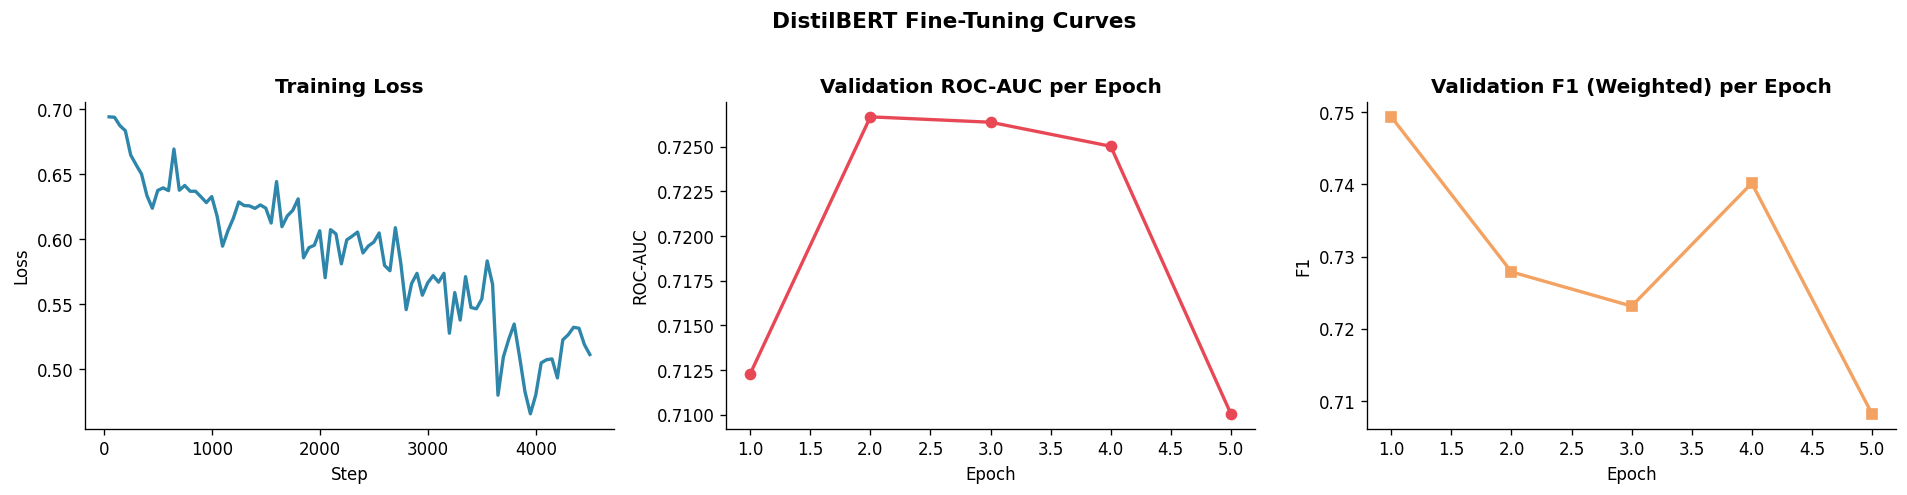

In [7]:
# Extract Training and Evaluation Logs
log_history = trainer.state.log_history

train_logs = [
    x for x in log_history
    if 'loss' in x and 'eval_loss' not in x
]

eval_logs = [
    x for x in log_history
    if 'eval_loss' in x
]

# Plot Training Curves (If Logs Available)
if train_logs and eval_logs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Training Loss vs Steps
    axes[0].plot(
        [x['step'] for x in train_logs],
        [x['loss'] for x in train_logs],
        color=PALETTE[0],
        lw=2
    )
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

    # Validation ROC-AUC per Epoch
    axes[1].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_roc_auc', 0) for x in eval_logs],
        'o-',
        color=PALETTE[1],
        lw=2,
        markersize=6
    )
    axes[1].set_title('Validation ROC-AUC per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC')

    # Validation Weighted F1 per Epoch
    axes[2].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_f1_weighted', 0) for x in eval_logs],
        's-',
        color=PALETTE[2],
        lw=2,
        markersize=6
    )
    axes[2].set_title('Validation F1 (Weighted) per Epoch', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1')

    # Figure Formatting and Save
    plt.suptitle(
        'DistilBERT Fine-Tuning Curves',
        fontsize=13,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout()

    plt.savefig(
        f'{DISTILBERT_PLOTS_DIR}/db_01_training_curves.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

## Test Set Evaluation and Performance Visualisation

This section evaluates the trained model on the held-out test set and visualises its predictive performance.

- Generates predictions on the test dataset using the trained model
- Extracts:
  - Predicted class labels
  - Class probabilities for the positive class
- Computes evaluation metrics including:
  - ROC-AUC
  - Precision-Recall AUC
  - Classification report (precision, recall, F1-score)
- Outputs detailed performance metrics for both classes
- Generates visualisations for:
  - ROC curve with baseline comparison
  - Precision-Recall curve with class imbalance baseline
  - Confusion matrix for classification outcomes
- Saves evaluation plots for reporting and reproducibility


=== DistilBERT -- Test Set Results ===
                precision    recall  f1-score   support

Not Readmitted       0.88      0.71      0.78      2916
    Readmitted       0.32      0.58      0.41       694

      accuracy                           0.68      3610
     macro avg       0.60      0.64      0.60      3610
  weighted avg       0.77      0.68      0.71      3610

ROC-AUC : 0.7043   PR-AUC : 0.4023


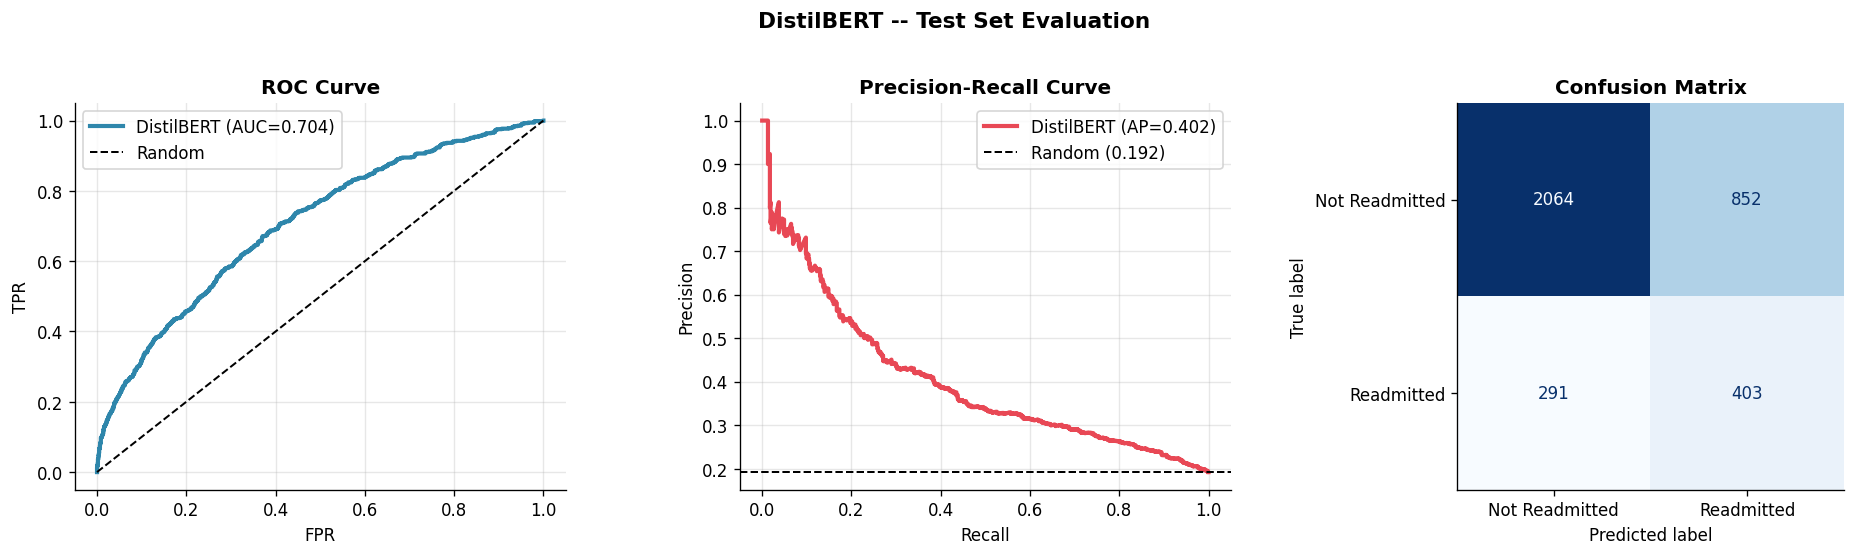

In [8]:
# Test Set Prediction
pred_out = trainer.predict(test_ds)

# Logits, Predicted Labels, and Probabilities
logits = pred_out.predictions
y_pred = np.argmax(logits, axis=-1)

y_prob = torch.softmax(
    torch.tensor(logits, dtype=torch.float32),
    dim=-1
).numpy()[:, 1]

# Evaluation Metrics (Test Set)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Results Output
print('\n=== DistilBERT -- Test Set Results ===')
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Readmitted', 'Readmitted'],
    zero_division=0
))
print(f'ROC-AUC : {roc_auc:.4f}   PR-AUC : {pr_auc:.4f}')

# Curve Computation (ROC and Precision-Recall)
fpr, tpr, _  = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

# Plot Evaluation Metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC Curve
axes[0].plot(
    fpr, tpr,
    color=PALETTE[0],
    lw=2.5,
    label=f'DistilBERT (AUC={roc_auc:.3f})'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(
    rec, prec,
    color=PALETTE[1],
    lw=2.5,
    label=f'DistilBERT (AP={pr_auc:.3f})'
)
axes[1].axhline(
    y=y_test.mean(),
    color='k',
    linestyle='--',
    lw=1.2,
    label=f'Random ({y_test.mean():.3f})'
)
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Readmitted', 'Readmitted']
).plot(ax=axes[2], colorbar=False, cmap='Blues')

axes[2].set_title('Confusion Matrix', fontweight='bold')

# Figure Formatting and Save
plt.suptitle(
    'DistilBERT -- Test Set Evaluation',
    fontsize=13,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()

plt.savefig(
    f'{DISTILBERT_PLOTS_DIR}/db_02_test_evaluation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Prediction Confidence Analysis

This section analyses the distribution of model prediction probabilities to assess confidence and error behaviour.

- Visualises predicted probabilities grouped by true class labels:
  - Not readmitted
  - Readmitted
- Highlights the decision threshold (0.5) to distinguish classification regions
- Analyses confidence based on prediction correctness:
  - Correct predictions
  - Incorrect predictions
- Identifies patterns in model certainty and misclassification behaviour
- Provides insight into:
  - Calibration of predicted probabilities
  - Separation between classes
- Saves visualisations for further evaluation and reporting

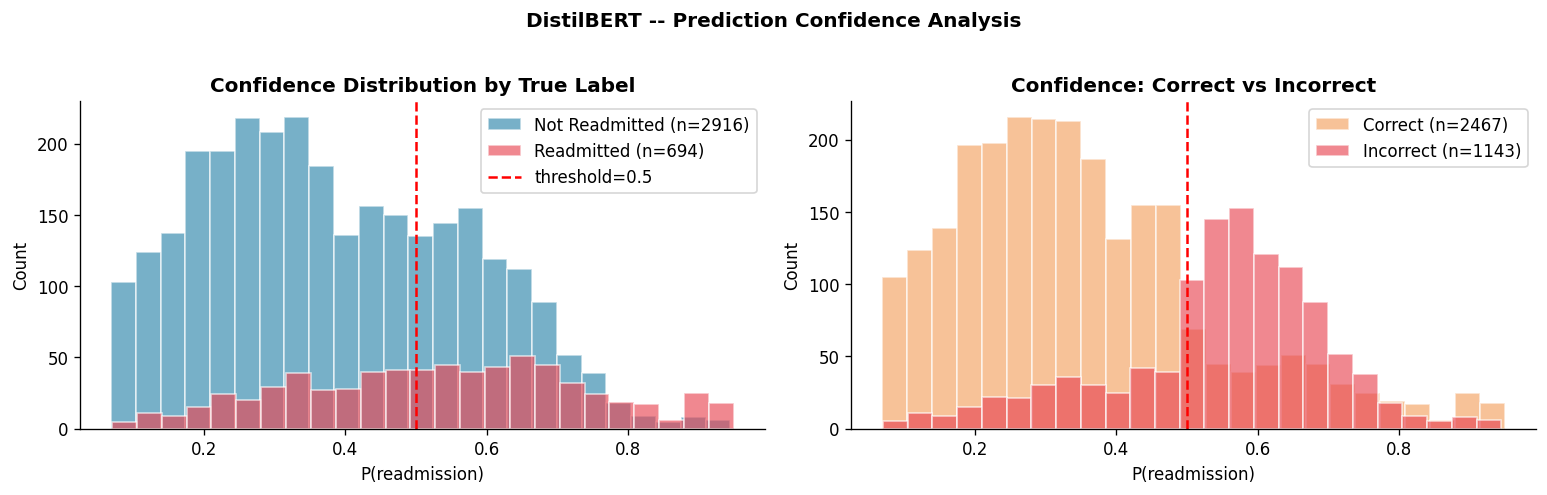

In [9]:
# Confidence Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence by True Label
for label, color, name in [
    (0, PALETTE[0], 'Not Readmitted'),
    (1, PALETTE[1], 'Readmitted')
]:
    sub = y_prob[y_test == label]

    axes[0].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{name} (n={len(sub)})'
    )

# Decision Threshold Line
axes[0].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5,
    label='threshold=0.5'
)

axes[0].set_title('Confidence Distribution by True Label', fontweight='bold')
axes[0].set_xlabel('P(readmission)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence by Prediction Correctness
correct = (y_pred == y_test)

for flag, color, lbl in [
    (True, PALETTE[2], 'Correct'),
    (False, PALETTE[1], 'Incorrect')
]:
    sub = y_prob[correct == flag]

    axes[1].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{lbl} (n={len(sub)})'
    )

# Decision Threshold Line
axes[1].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5
)

axes[1].set_title('Confidence: Correct vs Incorrect', fontweight='bold')
axes[1].set_xlabel('P(readmission)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Figure Formatting and Save
plt.suptitle(
    'DistilBERT -- Prediction Confidence Analysis',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{DISTILBERT_PLOTS_DIR}/db_03_confidence_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Results Persistence and Resource Cleanup

This section saves evaluation outputs and releases computational resources after model training and evaluation.

- Stores key performance metrics in a structured CSV file for comparison and reporting
- Serialises prediction outputs and evaluation artifacts using pickle:
  - Test labels and predictions
  - Predicted probabilities
  - Classification report and evaluation metrics
  - ROC and Precision-Recall curve data
- Enables reproducibility and downstream analysis without recomputation
- Frees memory by deleting model and trainer objects
- Clears GPU cache and synchronises memory (if CUDA is available)
- Outputs final performance metrics and confirms completion of the pipeline

In [10]:
# Save Evaluation Metrics to CSV
pd.DataFrame([{
    'Model'         : 'DistilBERT',
    'Model_ID'      : DISTILBERT_MODEL_ID,
    'Type'          : 'Transformer',
    'Domain'        : 'General English',
    'Accuracy'      : report['accuracy'],
    'Precision_Pos' : report['1']['precision'],
    'Recall_Pos'    : report['1']['recall'],
    'F1_Pos'        : report['1']['f1-score'],
    'F1_Weighted'   : report['weighted avg']['f1-score'],
    'ROC_AUC'       : roc_auc,
    'PR_AUC'        : pr_auc,
}]).to_csv(
    DISTILBERT_RESULTS_CSV,
    index=False
)

# Save Predictions and Evaluation Artifacts (Pickle)
with open(DISTILBERT_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'y_test' : y_test,
        'y_pred' : y_pred,
        'y_prob' : y_prob,
        'X_test' : X_test,
        'report' : report,
        'roc_auc': roc_auc,
        'pr_auc' : pr_auc,
        'fpr'    : fpr,
        'tpr'    : tpr,
        'prec'   : prec,
        'rec'    : rec,
    }, f)

# Final Metric Summary
print(f'\nROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')


ROC-AUC : 0.7043  |  PR-AUC : 0.4023
